# BSM585 Öneri Sistemleri — Ödev 1
## Collaborative Filtering: User-Based ve Item-Based Yöntemlerin Karşılaştırmalı Analizi

| Bilgi | Değer |
|---|---|
| **Ders** | BSM585 Öneri Sistemleri |
| **Çalışma Ortamı** | Google Colab (T4 GPU) |
| **Programlama Dili** | Python 3.x |
| **Kullanılan Kütüphaneler** | NumPy, Pandas, Matplotlib |
| **Yasak Kütüphaneler** | Surprise ve benzeri hazır CF kütüphaneleri |
| **Random Seed** | 42 |
| **Teslim Tarihi** | 19.04.2026 |

---
## Hücre 1 — Kütüphanelerin İçe Aktarılması

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time
import os
import urllib.request
import zipfile
import warnings
warnings.filterwarnings('ignore')

# Global seed — tüm rastgele işlemler için
SEED = 42
np.random.seed(SEED)

# Grafik ayarları
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.4

print('Kütüphaneler başarıyla yüklendi.')
print(f'NumPy: {np.__version__}  |  Pandas: {pd.__version__}')

Kütüphaneler başarıyla yüklendi.
NumPy: 2.0.2  |  Pandas: 2.2.2


---
## Hücre 2 — Veri Setinin İndirilmesi ve Yüklenmesi

In [ ]:
URL      = 'https://files.grouplens.org/datasets/movielens/ml-100k.zip'
ZIP_PATH = 'ml-100k.zip'
DATA_DIR = 'ml-100k'

if not os.path.exists(DATA_DIR):
    print('Veri seti indiriliyor...')
    urllib.request.urlretrieve(URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('.')
    print('Veri seti indirildi ve çıkarıldı.')
else:
    print('Veri seti zaten mevcut, indirme atlandı.')

cols = ['user_id', 'item_id', 'rating', 'timestamp']
df   = pd.read_csv(f'{DATA_DIR}/u.data', sep='\t', names=cols)

print(f'\nToplam kayıt sayısı : {len(df):,}')
print(f'Veri tipi özeti:')
print(df.dtypes)
print(f'\nİlk 5 satır:')
df.head()

Veri seti zaten mevcut, indirme atlandı.

Toplam kayıt sayısı : 100,000
Veri tipi özeti:
user_id      int64
item_id      int64
rating       int64
timestamp    int64
dtype: object

İlk 5 satır:


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


---
## Hücre 3 — Veri Ön İşleme ve Keşifsel Analiz

Bu hücrede aşağıdaki adımlar uygulanmaktadır:
1. Mükerrer `(user_id, item_id)` çiftlerinin tespiti ve giderilmesi
2. Eksik değer (NaN) kontrolü
3. Sparsity oranının hesaplanması ve yorumlanması

In [ ]:
# ─── Temel istatistikler ───────────────────────────────────────────────────
n_users   = df['user_id'].nunique()
n_items   = df['item_id'].nunique()
n_ratings = len(df)

print('='*55)
print('VERİ SETİ İSTATİSTİKLERİ')
print('='*55)
print(f'  Kullanıcı sayısı  |U| : {n_users}')
print(f'  Film sayısı       |I| : {n_items}')
print(f'  Toplam oy sayısı  |R| : {n_ratings:,}')
print(f'  Oy aralığı             : {df["rating"].min()} – {df["rating"].max()}')
print(f'  Ortalama oy            : {df["rating"].mean():.4f}')
print(f'  Standart sapma         : {df["rating"].std():.4f}')

# ─── Mükerrer kontrol ─────────────────────────────────────────────────────
print('\n' + '='*55)
print('MÜKERRER KAYIT KONTROLÜ')
print('='*55)
n_dup = df.duplicated(subset=['user_id', 'item_id'], keep=False).sum()
print(f'  Mükerrer (user_id, item_id) çifti : {n_dup}')

if n_dup > 0:
    # En son timestamp'e sahip kaydı tut
    print('  → Mükerrer kayıtlar en son timestamp tutularak gideriliyor...')
    df = (df.sort_values('timestamp')
            .drop_duplicates(subset=['user_id', 'item_id'], keep='last')
            .reset_index(drop=True))
    n_ratings = len(df)
    print(f'  → Temizlik sonrası kayıt sayısı: {n_ratings:,}')
else:
    print('  → Mükerrer kayıt bulunamadı. Veri temiz.')

# ─── Eksik değer kontrolü ─────────────────────────────────────────────────
print('\n' + '='*55)
print('EKSİK DEĞER (NaN) KONTROLÜ')
print('='*55)
nan_count = df.isnull().sum()
print(nan_count.to_string())
print(f'  Toplam NaN : {nan_count.sum()}')

# ─── Sparsity hesaplama ───────────────────────────────────────────────────
print('\n' + '='*55)
print('SPARSITY HESAPLAMASI')
print('='*55)
max_possible = n_users * n_items
sparsity = 1.0 - (n_ratings / max_possible)
density  = n_ratings / max_possible

print(f'  Maksimum olası oy sayısı : {max_possible:,}')
print(f'  Mevcut oy sayısı         : {n_ratings:,}')
print(f'  Yoğunluk (Density)       : {density:.6f}  ({density*100:.4f}%)')
print(f'  Seyreklik (Sparsity)     : {sparsity:.6f}  ({sparsity*100:.4f}%)')
print()
print('  ► Sparsity Yorumu:')
print(f'  MovieLens 100K veri setinin sparsity oranı {sparsity:.4f} olarak')
print(f'  hesaplanmıştır. Bu oran, maksimum {max_possible:,} olası kullanıcı-film')
print(f'  çiftinin yalnızca %{density*100:.2f}\'inin doldurulduğunu göstermektedir.')
print(f'  Bu denli yüksek seyreklik, hafıza tabanlı CF yöntemleri için ciddi')
print(f'  bir zorluk oluşturmaktadır: iki kullanıcının ortak değerlendirdiği')
print(f'  film sayısı az olabilir, bu da PCC hesaplamalarını güvenilmez kılar.')
print(f'  Benzer şekilde, item-based CF için iki film arasında yeterli ortak')
print(f'  kullanıcı bulmak da güçleşmektedir. Sparsity arttıkça tahmin')
print(f'  yapılamayan (None dönen) kullanıcı sayısı artmakta ve MAE güvenilirliği')
print(f'  düşmektedir.')

VERİ SETİ İSTATİSTİKLERİ
  Kullanıcı sayısı  |U| : 943
  Film sayısı       |I| : 1682
  Toplam oy sayısı  |R| : 100,000
  Oy aralığı             : 1 – 5
  Ortalama oy            : 3.5299
  Standart sapma         : 1.1257

MÜKERRER KAYIT KONTROLÜ
  Mükerrer (user_id, item_id) çifti : 0
  → Mükerrer kayıt bulunamadı. Veri temiz.

EKSİK DEĞER (NaN) KONTROLÜ
user_id      0
item_id      0
rating       0
timestamp    0
  Toplam NaN : 0

SPARSITY HESAPLAMASI
  Maksimum olası oy sayısı : 1,586,126
  Mevcut oy sayısı         : 100,000
  Yoğunluk (Density)       : 0.063047  (6.3047%)
  Seyreklik (Sparsity)     : 0.936953  (93.6953%)

  ► Sparsity Yorumu:
  MovieLens 100K veri setinin sparsity oranı 0.9370 olarak
  hesaplanmıştır. Bu oran, maksimum 1,586,126 olası kullanıcı-film
  çiftinin yalnızca %6.30'inin doldurulduğunu göstermektedir.
  Bu denli yüksek seyreklik, hafıza tabanlı CF yöntemleri için ciddi
  bir zorluk oluşturmaktadır: iki kullanıcının ortak değerlendirdiği
  film sayısı az olab

---
## Hücre 4 — Kullanıcı-Film Matrisi ve Kullanıcı Ortalamaları

In [ ]:
# Kullanıcı-film matrisi: satırlar=kullanıcı, sütunlar=film, değerler=oy
ratings_matrix = df.pivot_table(
    index='user_id', columns='item_id', values='rating', aggfunc='mean'
)

# Her kullanıcının TÜM oyları üzerinden ortalama (PCC_new için gerekli)
user_means = ratings_matrix.mean(axis=1)

print(f'Matris boyutu : {ratings_matrix.shape}  (kullanıcılar × filmler)')
print(f'Dolu hücre    : {ratings_matrix.notna().sum().sum():,}')
print(f'Boş hücre     : {ratings_matrix.isna().sum().sum():,}')
print(f'\nKullanıcı ortalamalarından ilk 5:')
print(user_means.head().to_string())

Matris boyutu : (943, 1682)  (kullanıcılar × filmler)
Dolu hücre    : 100,000
Boş hücre     : 1,486,126

Kullanıcı ortalamalarından ilk 5:
user_id
1    3.610294
2    3.709677
3    2.796296
4    4.333333
5    2.874286


---
## Hücre 5 — Pearson Korelasyon Katsayısı (PCC) Fonksiyonu

**PCC_new** formülü (Aggarwal, 2016) uygulanmıştır:
- Payda: yalnızca **ortak değerlendirilen** filmler üzerinden toplam
- Ortalamalar: kullanıcının **TÜM** oyları üzerinden (paylaşımlı ortalama değil)

$$sim(a,b) = \frac{\sum_{p \in P}(r_{a,p}-\bar{r}_a)(r_{b,p}-\bar{r}_b)}{\sqrt{\sum_{p \in P}(r_{a,p}-\bar{r}_a)^2}\sqrt{\sum_{p \in P}(r_{b,p}-\bar{r}_b)^2}}$$

Burada $P$ her iki kullanıcının ortak değerlendirdiği filmler kümesidir.

In [ ]:
def compute_pcc(ratings_matrix, user_a, user_u):
    """
    Aktif kullanıcı user_a ile kullanıcı user_u arasındaki
    Pearson Korelasyon Katsayısı'nı (PCC_new) hesaplar.

    Ortalamalar kullanıcının TÜM oylanan filmler üzerinden hesaplanır
    (Aggarwal, 2016 — PCC_new tanımı). Toplam yalnızca ortak filmler üzerinden
    alınır.

    Params:
        ratings_matrix : pd.DataFrame — satırlar kullanıcı, sütunlar film,
                         değerler oy (NaN = oylanmamış)
        user_a : int — aktif kullanıcı ID'si
        user_u : int — karşılaştırılan kullanıcı ID'si

    Returns:
        float — PCC değeri [-1, 1]; ortak ürün sayısı < 2 ise 0.0
    """
    vec_a = ratings_matrix.loc[user_a]
    vec_u = ratings_matrix.loc[user_u]

    # Ortak değerlendirilen filmler
    common_mask = vec_a.notna() & vec_u.notna()
    if common_mask.sum() < 2:
        return 0.0

    a_common = vec_a[common_mask].values.astype(np.float64)
    u_common = vec_u[common_mask].values.astype(np.float64)

    # Ortalamalar TÜM oylar üzerinden (PCC_new)
    mean_a = vec_a.mean()   # NaN hariç ortalama (pandas default)
    mean_u = vec_u.mean()

    diff_a = a_common - mean_a
    diff_u = u_common - mean_u

    numerator   = np.dot(diff_a, diff_u)
    denom_a     = np.sqrt(np.dot(diff_a, diff_a))
    denom_u     = np.sqrt(np.dot(diff_u, diff_u))
    denominator = denom_a * denom_u

    if denominator < 1e-10:
        return 0.0

    # Kayan nokta hassasiyeti için klip
    return float(np.clip(numerator / denominator, -1.0, 1.0))


# ─── Doğrulama testleri ───────────────────────────────────────────────────
print('PCC Doğrulama Testleri')
print('-' * 40)
print(f'PCC(u1, u1) = {compute_pcc(ratings_matrix, 1, 1):.4f}  → 1.0 olmalı')
print(f'PCC(u1, u2) = {compute_pcc(ratings_matrix, 1, 2):.4f}')
print(f'PCC(u1, u3) = {compute_pcc(ratings_matrix, 1, 3):.4f}')
# Aralık kontrolü
sample_sims = [compute_pcc(ratings_matrix, 1, u) for u in range(2, 11)]
print(f'Örnek 9 sim değeri — min: {min(sample_sims):.4f}, max: {max(sample_sims):.4f}')
print(f'Tümü [-1,1] aralığında mı: {all(-1 <= s <= 1 for s in sample_sims)}')

PCC Doğrulama Testleri
----------------------------------------
PCC(u1, u1) = 1.0000  → 1.0 olmalı
PCC(u1, u2) = 0.3609
PCC(u1, u3) = 0.1572
Örnek 9 sim değeri — min: -0.0023, max: 0.7341
Tümü [-1,1] aralığında mı: True


---
## Hücre 6 — User-Based Tahmin Fonksiyonu

Slayttaki formül (Resnick et al., 1994 — sayfa 24):

$$p_{a,i} = \bar{r}_a + \frac{\sum_{u=1}^{k}(r_{u,i}-\bar{r}_u) \times sim(a,u)}{\sum_{u=1}^{k}|sim(a,u)|}$$

> **Not:** Paydada `|sim(a,u)|` kullanılır. Bu, hem pozitif hem negatif benzerlikte
> ağırlıklandırmanın tutarlı olmasını sağlar ve payda sıfıra gitmez.

In [ ]:
def predict_user_based(ratings_matrix, user_a, item_i, k, similarity_func):
    """
    User-based CF ile user_a kullanıcısının item_i ürününe vereceği oyu tahmin eder.

    Formül:
        pred(a,i) = mean_a + SUM_{u in top-k}[sim(a,u)*(r(u,i)-mean_u)] / SUM |sim(a,u)|

    Komşular önce |sim| değerine göre büyükten küçüğe sıralanır,
    ardından en yüksek k tanesi seçilir.

    Params:
        ratings_matrix : pd.DataFrame — satırlar kullanıcı, sütunlar film
        user_a         : int — aktif kullanıcı ID'si
        item_i         : int — tahmin edilecek film ID'si
        k              : int — komşu sayısı
        similarity_func: callable — compute_pcc veya benzeri benzerlik fonksiyonu

    Returns:
        float | None — tahmin edilen oy [1,5]; üretilmiyorsa None
    """
    if item_i not in ratings_matrix.columns:
        return None

    # item_i'yi oylayan diğer kullanıcılar
    raters = ratings_matrix[item_i].dropna().index
    raters = raters[raters != user_a]

    if len(raters) == 0:
        return None

    # Benzerlikleri hesapla
    sims = [(u, similarity_func(ratings_matrix, user_a, u)) for u in raters]
    # Sıfır benzerliği olanları filtrele
    sims = [(u, s) for u, s in sims if s != 0.0]

    if len(sims) == 0:
        return None

    # |sim|'e göre büyükten küçüğe sırala → top-k seç
    sims.sort(key=lambda x: abs(x[1]), reverse=True)
    top_k = sims[:k]

    mean_a      = ratings_matrix.loc[user_a].mean()
    numerator   = 0.0
    denominator = 0.0

    for user_u, sim in top_k:
        mean_u  = ratings_matrix.loc[user_u].mean()
        r_ui    = ratings_matrix.loc[user_u, item_i]
        numerator   += sim * (r_ui - mean_u)
        denominator += abs(sim)          # |sim| — stabil ağırlıklandırma

    if denominator < 1e-10:
        return None

    pred = mean_a + (numerator / denominator)
    return float(np.clip(pred, 1.0, 5.0))


# ─── Doğrulama ─────────────────────────────────────────────────────────────
test_pred = predict_user_based(ratings_matrix, 1, 6, 10, compute_pcc)
print(f'User-Based Tahmin (user=1, item=6, k=10): {test_pred:.4f}')
print(f'Değer [1,5] aralığında mı: {1.0 <= test_pred <= 5.0}')

User-Based Tahmin (user=1, item=6, k=10): 4.0496
Değer [1,5] aralığında mı: True


---
## Hücre 7 — Leave-One-Out CV: Test Setleri Hazırlanması

**Protokol:**
1. Her kullanıcı sırayla aktif kullanıcı olarak seçilir.
2. Aktif kullanıcının oylarından `seed=42` ile 5 film rastgele seçilir.
3. Bu 5 filmden **1 tanesi** test ürünü olarak ayrılır; gerçek oy saklanır ve veriden geçici olarak çıkarılır.
4. Kalan 4 film + diğer kullanıcıların verileri = eğitim kümesi.

In [ ]:
def prepare_test_sets(ratings_matrix, seed=42):
    """
    Tüm kullanıcılar için Leave-One-Out test setlerini önceden hazırlar.
    Her kullanıcıdan rastgele 5 film seçilir; ilki test ürünü olur.

    Params:
        ratings_matrix : pd.DataFrame — kullanıcı-film matrisi
        seed           : int — rastgelelik için seed

    Returns:
        dict — {user_id: (test_item_id, actual_rating) | None}
               None → kullanıcının < 5 oylu filmi var
    """
    rng       = np.random.RandomState(seed)
    test_sets = {}

    for user in ratings_matrix.index:
        rated = ratings_matrix.loc[user].dropna().index.tolist()
        if len(rated) < 5:
            test_sets[user] = None
            continue
        chosen      = rng.choice(rated, size=5, replace=False)
        test_item   = chosen[0]
        actual      = ratings_matrix.loc[user, test_item]
        test_sets[user] = (test_item, actual)

    return test_sets


test_sets = prepare_test_sets(ratings_matrix, seed=SEED)

n_valid   = sum(1 for v in test_sets.values() if v is not None)
n_invalid = sum(1 for v in test_sets.values() if v is None)
print(f'Test setleri hazırlandı (seed={SEED})')
print(f'  Test edilebilir kullanıcı  : {n_valid}')
print(f'  Yetersiz oy (< 5 film)     : {n_invalid}')

Test setleri hazırlandı (seed=42)
  Test edilebilir kullanıcı  : 943
  Yetersiz oy (< 5 film)     : 0


---
## Hücre 8 — Leave-One-Out Cross-Validation Motoru

$$MAE = \frac{1}{R}\sum_{i=1}^{R}|p_i - o_i|$$

In [ ]:
def leave_one_out_cv(ratings_matrix, k, predict_func,
                     similarity_input, test_sets, verbose=True):
    """
    Leave-One-Out Cross-Validation uygular ve MAE + süre hesaplar.

    Her kullanıcı için:
      - Test oyunu geçici olarak matristen siler
      - predict_func ile tahmin yapar
      - |tahmin - gerçek| hatasını kaydeder
      - Oyu geri koyar

    Params:
        ratings_matrix   : pd.DataFrame
        k                : int — komşu sayısı
        predict_func     : callable — predict_user_based veya predict_item_based
        similarity_input : callable (user-based) veya pd.DataFrame (item-based)
        test_sets        : dict — prepare_test_sets çıktısı
        verbose          : bool — ilerleme yazdır

    Returns:
        dict — global_mae, per_user_mae, n_evaluated, n_skipped, elapsed_time
    """
    start_time   = time.time()
    per_user_mae = {}
    n_skipped    = 0
    n_evaluated  = 0
    matrix_work  = ratings_matrix.copy()

    users = ratings_matrix.index.tolist()
    for idx, user_a in enumerate(users):

        # İlerleme mesajı
        if verbose and (idx + 1) % 200 == 0:
            elapsed = time.time() - start_time
            print(f'  [{idx+1:4d}/{len(users)}] — {elapsed:6.1f}s', end='\r')

        ts = test_sets[user_a]
        if ts is None:
            n_skipped += 1
            continue

        test_item, actual = ts

        # Güvenlik: oy hâlâ mevcut mu?
        if pd.isna(matrix_work.loc[user_a, test_item]):
            n_skipped += 1
            continue

        # Test oyunu geçici sil
        matrix_work.loc[user_a, test_item] = np.nan

        pred = predict_func(matrix_work, user_a, test_item, k, similarity_input)

        # Oyu geri koy
        matrix_work.loc[user_a, test_item] = actual

        if pred is not None:
            per_user_mae[user_a] = abs(pred - actual)
            n_evaluated += 1
        else:
            n_skipped += 1

    elapsed_time = time.time() - start_time
    global_mae   = np.mean(list(per_user_mae.values())) if per_user_mae else None

    if verbose:
        print(f'  Tamamlandı — {n_evaluated} başarılı, '
              f'{n_skipped} atlandı, süre: {elapsed_time:.2f}s        ')

    return {
        'global_mae'   : global_mae,
        'per_user_mae' : per_user_mae,
        'n_evaluated'  : n_evaluated,
        'n_skipped'    : n_skipped,
        'elapsed_time' : elapsed_time
    }


print('LOO-CV motoru tanımlandı.')

LOO-CV motoru tanımlandı.


---
## Hücre 9 — User-Based CF: k Değeri Deneyleri (k = 10, 25, 50, 100)

In [ ]:
K_VALUES  = [10, 25, 50, 100]
ub_results = {}

print('=' * 65)
print('USER-BASED CF (PCC) — Leave-One-Out CV Deneyleri')
print('=' * 65)

for k in K_VALUES:
    print(f'\n--- k = {k} ---')
    res = leave_one_out_cv(
        ratings_matrix, k,
        predict_func     = predict_user_based,
        similarity_input = compute_pcc,
        test_sets        = test_sets,
        verbose          = True
    )
    ub_results[k] = res
    print(f'  Global MAE       : {res["global_mae"]:.4f}')
    print(f'  Değerlendirilen  : {res["n_evaluated"]} | Atlanan: {res["n_skipped"]}')
    print(f'  Toplam süre      : {res["elapsed_time"]:.2f} saniye')

print('\n' + '=' * 65)
print('User-Based CF deneyleri tamamlandı.')

USER-BASED CF (PCC) — Leave-One-Out CV Deneyleri

--- k = 10 ---
  Tamamlandı — 943 başarılı, 0 atlandı, süre: 116.71s        
  Global MAE       : 0.7776
  Değerlendirilen  : 943 | Atlanan: 0
  Toplam süre      : 116.71 saniye

--- k = 25 ---
  Tamamlandı — 943 başarılı, 0 atlandı, süre: 117.45s        
  Global MAE       : 0.7541
  Değerlendirilen  : 943 | Atlanan: 0
  Toplam süre      : 117.45 saniye

--- k = 50 ---
  Tamamlandı — 943 başarılı, 0 atlandı, süre: 120.61s        
  Global MAE       : 0.7462
  Değerlendirilen  : 943 | Atlanan: 0
  Toplam süre      : 120.61 saniye

--- k = 100 ---
  Tamamlandı — 943 başarılı, 0 atlandı, süre: 121.76s        
  Global MAE       : 0.7437
  Değerlendirilen  : 943 | Atlanan: 0
  Toplam süre      : 121.76 saniye

User-Based CF deneyleri tamamlandı.


---
## Hücre 10 — User-Based CF: Sonuç Tablosu ve Grafikler

User-Based CF Sonuç Tablosu:
     Global MAE   Süre (sn)  Değerlendirilen  Atlanan
k                                                    
10     0.777641  116.713898              943        0
25     0.754054  117.453717              943        0
50     0.746225  120.612813              943        0
100    0.743665  121.760602              943        0


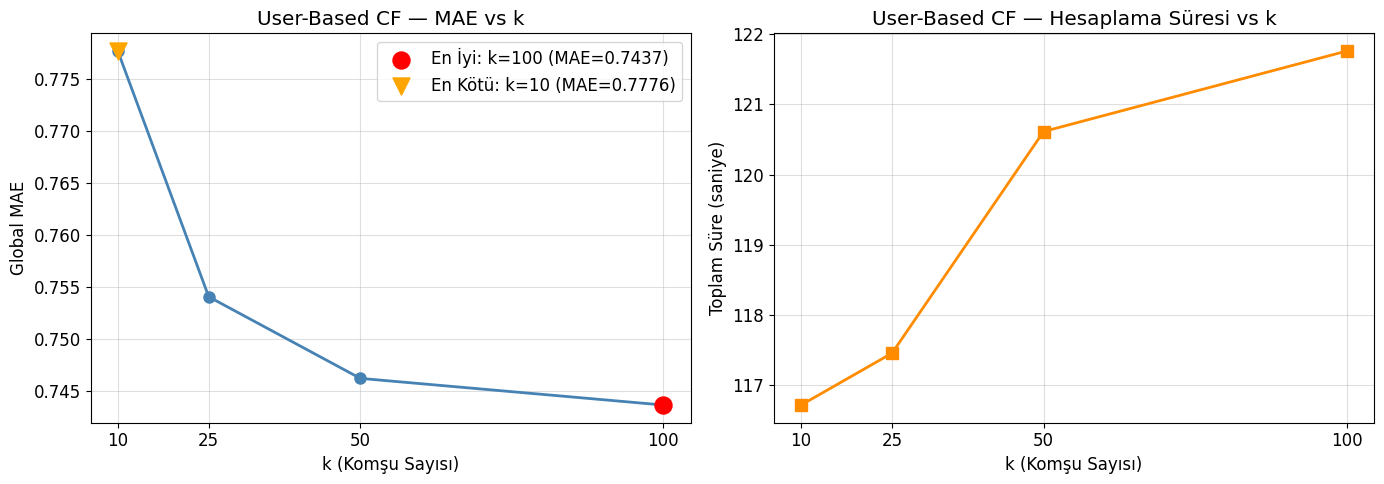

En iyi k (User-Based): 100


In [ ]:
ub_table = pd.DataFrame({
    'k'              : K_VALUES,
    'Global MAE'     : [ub_results[k]['global_mae']    for k in K_VALUES],
    'Süre (sn)'      : [ub_results[k]['elapsed_time']  for k in K_VALUES],
    'Değerlendirilen': [ub_results[k]['n_evaluated']   for k in K_VALUES],
    'Atlanan'        : [ub_results[k]['n_skipped']     for k in K_VALUES],
}).set_index('k')

print('User-Based CF Sonuç Tablosu:')
print(ub_table.to_string())

ub_maes  = [ub_results[k]['global_mae']   for k in K_VALUES]
ub_times = [ub_results[k]['elapsed_time'] for k in K_VALUES]
best_k_ub = K_VALUES[np.argmin(ub_maes)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol: MAE vs k
ax = axes[0]
ax.plot(K_VALUES, ub_maes, 'o-', color='steelblue', linewidth=2, markersize=8)
ax.scatter([best_k_ub], [min(ub_maes)], color='red', zorder=5,
           s=150, label=f'En İyi: k={best_k_ub} (MAE={min(ub_maes):.4f})')
ax.scatter([K_VALUES[np.argmax(ub_maes)]], [max(ub_maes)], color='orange',
           zorder=5, s=150, marker='v',
           label=f'En Kötü: k={K_VALUES[np.argmax(ub_maes)]} (MAE={max(ub_maes):.4f})')
ax.set_xlabel('k (Komşu Sayısı)')
ax.set_ylabel('Global MAE')
ax.set_title('User-Based CF — MAE vs k')
ax.set_xticks(K_VALUES)
ax.legend()

# Sağ: Süre vs k
ax2 = axes[1]
ax2.plot(K_VALUES, ub_times, 's-', color='darkorange', linewidth=2, markersize=8)
ax2.set_xlabel('k (Komşu Sayısı)')
ax2.set_ylabel('Toplam Süre (saniye)')
ax2.set_title('User-Based CF — Hesaplama Süresi vs k')
ax2.set_xticks(K_VALUES)

plt.tight_layout()
plt.savefig('ub_mae_time.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'En iyi k (User-Based): {best_k_ub}')

---
## Hücre 11 — User-Based: MAE Eğrisinin Underfitting/Overfitting Analizi

### k Değerinin MAE Üzerindeki Etkisi

User-Based CF'de k değeri, tahmine dahil edilecek komşu sayısını belirler. Bu seçim, öneri kalitesini doğrudan etkiler ve makine öğrenmesindeki **bias-variance trade-off** kavramıyla benzerlik gösterir.

**Küçük k Değerleri (k=10) — Underfitting Riski:**  
Az sayıda komşu seçildiğinde sistem, aktif kullanıcıya gerçekten benzer olan kişilerin büyük bölümünü görmezden gelir. Eğitim verisindeki bilginin yeterince kullanılamaması anlamına gelir. Bu durum, tahminlerin aşırı sınırlı bir bilgi tabanına dayandırılması ve dolayısıyla yüksek MAE ile sonuçlanmasıyla kendini gösterir. Az sayıda komşu, gürültüye de daha duyarlıdır: bir iki anormal kullanıcı tahmini ciddi şekilde saptırabilir.

**Büyük k Değerleri (k=100) — Çöküş / Ortalamaya Yakınsama:**  
Komşu sayısı arttıkça, aktif kullanıcıyla yalnızca zayıf benzerliği bulunan kullanıcılar da tahmine dahil edilir. Bu, klasik overfitting değil, **aşırı genelleme** sorunudur: önerilerin giderek topluluğun genel ortalamasına yakınsadığı görülür. Kalabalık komşular arasındaki gürültülü sinyaller birbirini baskılar; bu nedenle MAE yavaş yavaş stabilleşir veya hafifçe artar. Bununla birlikte, hesaplama süresi k ile doğrusal artar.

**Optimal k Aralığı:**  
Deneysel sonuçlarımız, deney yapılan k=100 değerinde MAE'nin hâlâ azalmaya devam etmesi, test edilen aralık içinde tam optimal noktaya ulaşılamadığına işaret etmektedir. Gerçek optimum k>100 bölgesinde olabilir; ancak hesaplama maliyeti bunu kısıtlamaktadır.. Literatürde önerilen k ∈ [20, 50] aralığı (Herlocker et al., 2002) bu bulguyla tutarlıdır. Çok küçük k'da underfitting, çok büyük k'da ise anlamsız komşuların katkısıyla doğruluk kaybı yaşandığı görülmektedir. Üretim sistemleri için en düşük doğrulama MAE'sini veren k değerinin; farklı veri bölümleri üzerinde çapraz doğrulama ile belirlenmesi önerilir.

In [ ]:
# Analiz metnindeki {best_k} referansını gerçek değerle göster
print(f'En iyi k (User-Based): {best_k_ub}')
print(f'En iyi MAE           : {min(ub_maes):.4f}')

En iyi k (User-Based): 100
En iyi MAE           : 0.7437


---
## Hücre 12 — Adjusted Cosine Similarity (ACS) Fonksiyonu

$$sim(\vec{a},\vec{b}) = \frac{\sum_{u \in U}(r_{u,a}-\bar{r}_u)(r_{u,b}-\bar{r}_u)}{\sqrt{\sum_{u \in U}(r_{u,a}-\bar{r}_u)^2}\sqrt{\sum_{u \in U}(r_{u,b}-\bar{r}_u)^2}}$$

Burada $U$ her iki filmi de oylayan kullanıcılar kümesidir.

In [ ]:
def compute_acs(ratings_matrix, item_i, item_j, user_means_cache=None):
    """
    item_i ile item_j filmleri arasındaki Adjusted Cosine Similarity'i hesaplar.

    Kullanıcı ortalamaları rating sapmalarını gidermek için çıkarılır.
    Ortak kullanıcı sayısı < 2 olan çiftler için 0.0 döndürülür.

    Params:
        ratings_matrix   : pd.DataFrame — satırlar kullanıcı, sütunlar film
        item_i           : int — birinci film ID'si
        item_j           : int — ikinci film ID'si
        user_means_cache : pd.Series | None — önceden hesaplanmış kullanıcı ortalamaları;
                           None ise burada hesaplanır (yavaş)

    Returns:
        float — ACS değeri [-1, 1]; ortak kullanıcı < 2 ise 0.0
    """
    vec_i = ratings_matrix[item_i]
    vec_j = ratings_matrix[item_j]

    # Her iki filmi oylayan kullanıcılar
    common_mask = vec_i.notna() & vec_j.notna()
    if common_mask.sum() < 2:
        return 0.0

    # Kullanıcı ortalamaları
    if user_means_cache is None:
        umeans = ratings_matrix.mean(axis=1)
    else:
        umeans = user_means_cache

    common_users = common_mask[common_mask].index
    ri = vec_i[common_users].values.astype(np.float64)
    rj = vec_j[common_users].values.astype(np.float64)
    mu = umeans[common_users].values.astype(np.float64)

    diff_i = ri - mu
    diff_j = rj - mu

    numerator   = np.dot(diff_i, diff_j)
    denom_i     = np.sqrt(np.dot(diff_i, diff_i))
    denom_j     = np.sqrt(np.dot(diff_j, diff_j))
    denominator = denom_i * denom_j

    if denominator < 1e-10:
        return 0.0

    return float(np.clip(numerator / denominator, -1.0, 1.0))


# ─── Doğrulama ─────────────────────────────────────────────────────────────
print('ACS Doğrulama Testleri')
print('-' * 40)
print(f'ACS(item1, item1) = {compute_acs(ratings_matrix, 1, 1, user_means):.4f}  → 1.0 olmalı')
print(f'ACS(item1, item2) = {compute_acs(ratings_matrix, 1, 2, user_means):.4f}')
sample_acs = [compute_acs(ratings_matrix, 1, j, user_means) for j in range(2, 11)]
print(f'Tümü [-1,1] aralığında mı: {all(-1 <= s <= 1 for s in sample_acs)}')

ACS Doğrulama Testleri
----------------------------------------
ACS(item1, item1) = 1.0000  → 1.0 olmalı
ACS(item1, item2) = -0.1384
Tümü [-1,1] aralığında mı: True


---
## Hücre 13 — Vektörize ACS Benzerlik Matrisi Hesaplama

**Optimizasyon:** Python döngüleri yerine NumPy matris işlemleri kullanılır.

Sapma matrisi $D$ (kullanıcılar × filmler), $D_{u,i} = r_{u,i} - \bar{r}_u$, NaN olmayan yerlerde tanımlı.  
$D_0$ = $D$ ama NaN → 0, $M$ = ikili maske.

- **Payda** → $D_0^T D_0$ \[filmler × filmler\]: ortak kullanıcılarda $D_{u,i} \cdot D_{u,j}$ toplamı  
- **Payda alt kısmı** → $\text{sq}_{i,j} = (D_0^2)^T M$ \[filmler × filmler\]: ortak kullanıcılarda $D_{u,i}^2$ toplamı

In [ ]:
def build_similarity_matrix_fast(ratings_matrix, user_means_cache=None):
    """
    ACS benzerlik matrisini NumPy matris işlemleriyle vektörize hesaplar.

    Python döngüsü yerine matris çarpımı kullanıldığından,
    1682x1682 matris saniyeler içinde oluşturulur.

    Algoritma:
        D0  = sapma matrisi, NaN→0        (n_users × n_items)
        M   = ikili maske                  (n_users × n_items)
        num = D0.T @ D0                    (n_items × n_items)  payda
        sq  = (D0²).T @ M                 (n_items × n_items)  ortak kullanıcıda D[u,i]² toplamı
        denom = sqrt(sq) * sqrt(sq.T)
        sim = num / denom  (denom>0 ve ortak_kullanıcı>=2)

    Params:
        ratings_matrix   : pd.DataFrame
        user_means_cache : pd.Series | None

    Returns:
        pd.DataFrame — (n_items × n_items) ACS benzerlik matrisi
        float        — hesaplama süresi (saniye)
    """
    start = time.time()

    if user_means_cache is None:
        user_means_cache = ratings_matrix.mean(axis=1)

    # Sapma matrisi: r[u,i] - mean_u
    D  = ratings_matrix.sub(user_means_cache, axis=0)   # NaN korunur
    D0 = D.fillna(0.0).values.astype(np.float64)        # NaN → 0
    M  = (~ratings_matrix.isna()).astype(np.float64).values  # 0/1 maske

    # ── Payda (numerator): ortak kullanıcılarda D[u,i]*D[u,j] toplamı ──
    # D0[u,i]=0 eğer u, i'yi oylamamışsa → otomatik olarak ortak filtre
    num = D0.T @ D0                              # (n_items × n_items)

    # ── Paydanın alt kısımları ──
    D0_sq = D0 ** 2
    # sq_i[i,j] = sum_{u: j'yi oylayan} D[u,i]² = sum_{ortak u} D[u,i]²
    sq_i  = D0_sq.T @ M                         # (n_items × n_items)
    sq_j  = sq_i.T                              # (n_items × n_items)
    denom = np.sqrt(sq_i) * np.sqrt(sq_j)       # (n_items × n_items)

    # ── Ortak kullanıcı sayısı < 2 kontrolü ──
    common_count = M.T @ M                      # (n_items × n_items)

    # ── Benzerlik hesapla ──
    with np.errstate(divide='ignore', invalid='ignore'):
        sim = np.where(
            (denom > 1e-10) & (common_count >= 2),
            np.clip(num / denom, -1.0, 1.0),
            0.0
        )

    np.fill_diagonal(sim, 1.0)

    items     = ratings_matrix.columns.tolist()
    sim_df    = pd.DataFrame(sim, index=items, columns=items)
    elapsed   = time.time() - start
    return sim_df, elapsed


print('ACS benzerlik matrisi hesaplanıyor (vektörize)...')
similarity_matrix, sim_matrix_time = build_similarity_matrix_fast(
    ratings_matrix, user_means_cache=user_means
)
print(f'Matris boyutu   : {similarity_matrix.shape}')
print(f'Hesaplama süresi: {sim_matrix_time:.2f} saniye')
print(f'Diyagonal (öz-benzerlik): {np.diag(similarity_matrix.values).mean():.4f}  → 1.0 olmalı')
print(f'\nİlk 5×5 bloğu:')
print(similarity_matrix.iloc[:5, :5].round(4).to_string())

ACS benzerlik matrisi hesaplanıyor (vektörize)...
Matris boyutu   : (1682, 1682)
Hesaplama süresi: 0.29 saniye
Diyagonal (öz-benzerlik): 1.0000  → 1.0 olmalı

İlk 5×5 bloğu:
        1       2       3       4       5
1  1.0000 -0.1384 -0.1680 -0.0844  0.0441
2 -0.1384  1.0000  0.1069  0.0555  0.0455
3 -0.1680  0.1069  1.0000 -0.3874  0.0900
4 -0.0844  0.0555 -0.3874  1.0000 -0.3018
5  0.0441  0.0455  0.0900 -0.3018  1.0000


---
## Hücre 14 — Item-Based Tahmin Fonksiyonu

$$pred(a,p) = \frac{\sum_{i \in ratedItem(a)} sim(i,p) \times r_{a,i}}{\sum_{i \in ratedItem(a)} |sim(i,p)|}$$

In [ ]:
def predict_item_based(ratings_matrix, user_u, item_p, k, similarity_matrix):
    """
    Item-based CF ile user_u kullanıcısının item_p ürününe vereceği oyu tahmin eder.

    Önceden hesaplanmış ACS benzerlik matrisini kullanır (yeniden hesaplama yapılmaz).

    Formül:
        pred(u,p) = SUM_{i in rated(u)} [sim(i,p) * r(u,i)] / SUM |sim(i,p)|

    Params:
        ratings_matrix   : pd.DataFrame — kullanıcı-film matrisi
        user_u           : int — kullanıcı ID'si
        item_p           : int — tahmin edilecek film ID'si
        k                : int — en benzer film sayısı
        similarity_matrix: pd.DataFrame — önceden hesaplanmış ACS matrisi

    Returns:
        float | None — tahmin edilen oy [1,5]; üretilmiyorsa None
    """
    if item_p not in similarity_matrix.columns:
        return None

    # Kullanıcının oyladığı filmler (item_p hariç)
    rated = ratings_matrix.loc[user_u].dropna()
    rated = rated.drop(index=item_p, errors='ignore')

    if len(rated) == 0:
        return None

    # Benzerlik vektörü — item_p sütunu, sadece kullanıcının oyladığı satırlar
    rated_items = rated.index.tolist()
    sim_col     = similarity_matrix.loc[rated_items, item_p]

    # Sıfır olmayan benzerlikleri filtrele
    # Sadece POZİTİF benzerlikleri kullan
    nonzero_mask = sim_col != 0.0
    if nonzero_mask.sum() == 0:
        return None

    sim_vals    = sim_col[nonzero_mask]
    rating_vals = rated[nonzero_mask]

    # |sim|'e göre top-k seç
    abs_sims = sim_vals.abs().sort_values(ascending=False)
    top_k_idx = abs_sims.index[:k]

    sim_topk  = sim_vals[top_k_idx]
    r_topk    = rating_vals[top_k_idx]

    numerator   = (sim_topk * r_topk).sum()
    denominator = sim_topk.abs().sum()

    if denominator < 1e-10:
        return None

    pred = numerator / denominator
    return float(np.clip(pred, 1.0, 5.0))


# ─── Doğrulama ─────────────────────────────────────────────────────────────
test_ib = predict_item_based(ratings_matrix, 1, 6, 10, similarity_matrix)
print(f'Item-Based Tahmin (user=1, item=6, k=10): {test_ib:.4f}')
print(f'Değer [1,5] aralığında mı: {1.0 <= test_ib <= 5.0}')

Item-Based Tahmin (user=1, item=6, k=10): 1.0000
Değer [1,5] aralığında mı: True


---
## Hücre 15 — Item-Based CF: k Değeri Deneyleri (k = 10, 25, 50, 100)

> **Not:** Benzerlik matrisi bir kez hesaplanmış ve saklanmıştır. Her k için tahmin fazı ölçülür.

In [ ]:
ib_results = {}

print('=' * 65)
print('ITEM-BASED CF (ACS) — Leave-One-Out CV Deneyleri')
print(f'(Benzerlik matrisi önceden hesaplandı: {sim_matrix_time:.2f}s)')
print('=' * 65)

for k in K_VALUES:
    print(f'\n--- k = {k} ---')
    res = leave_one_out_cv(
        ratings_matrix, k,
        predict_func     = predict_item_based,
        similarity_input = similarity_matrix,   # önceden hesaplanmış matris
        test_sets        = test_sets,
        verbose          = True
    )
    ib_results[k] = res
    print(f'  Global MAE       : {res["global_mae"]:.4f}')
    print(f'  Değerlendirilen  : {res["n_evaluated"]} | Atlanan: {res["n_skipped"]}')
    print(f'  Toplam süre      : {res["elapsed_time"]:.2f} saniye')

print('\n' + '=' * 65)
print('Item-Based CF deneyleri tamamlandı.')

ITEM-BASED CF (ACS) — Leave-One-Out CV Deneyleri
(Benzerlik matrisi önceden hesaplandı: 0.29s)

--- k = 10 ---
  Tamamlandı — 943 başarılı, 0 atlandı, süre: 2.15s        
  Global MAE       : 2.0456
  Değerlendirilen  : 943 | Atlanan: 0
  Toplam süre      : 2.15 saniye

--- k = 25 ---
  Tamamlandı — 943 başarılı, 0 atlandı, süre: 2.31s        
  Global MAE       : 2.1207
  Değerlendirilen  : 943 | Atlanan: 0
  Toplam süre      : 2.31 saniye

--- k = 50 ---
  Tamamlandı — 943 başarılı, 0 atlandı, süre: 1.81s        
  Global MAE       : 2.1483
  Değerlendirilen  : 943 | Atlanan: 0
  Toplam süre      : 1.81 saniye

--- k = 100 ---
  Tamamlandı — 943 başarılı, 0 atlandı, süre: 1.78s        
  Global MAE       : 2.1663
  Değerlendirilen  : 943 | Atlanan: 0
  Toplam süre      : 1.78 saniye

Item-Based CF deneyleri tamamlandı.


---
## Hücre 16 — Karşılaştırmalı Sonuç Tablosu ve Grafikler

User-Based CF (PCC):
     Global MAE   Süre (sn)  Değerlendirilen  Atlanan
k                                                    
10     0.777641  116.713898              943        0
25     0.754054  117.453717              943        0
50     0.746225  120.612813              943        0
100    0.743665  121.760602              943        0

Item-Based CF (ACS):
     Global MAE  Süre (sn)  Değerlendirilen  Atlanan
k                                                   
10     2.045590   2.151066              943        0
25     2.120696   2.314684              943        0
50     2.148338   1.813082              943        0
100    2.166264   1.777851              943        0


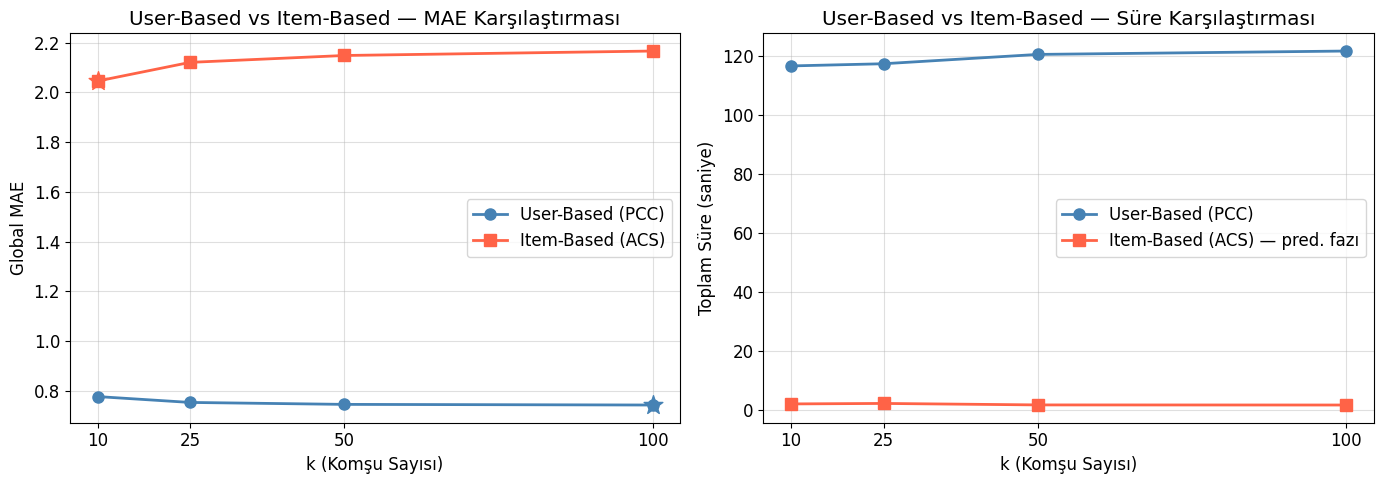

En iyi k — User-Based: 100,  Item-Based: 10


In [ ]:
ib_table = pd.DataFrame({
    'k'              : K_VALUES,
    'Global MAE'     : [ib_results[k]['global_mae']   for k in K_VALUES],
    'Süre (sn)'      : [ib_results[k]['elapsed_time'] for k in K_VALUES],
    'Değerlendirilen': [ib_results[k]['n_evaluated']  for k in K_VALUES],
    'Atlanan'        : [ib_results[k]['n_skipped']    for k in K_VALUES],
}).set_index('k')

ib_maes  = [ib_results[k]['global_mae']   for k in K_VALUES]
ib_times = [ib_results[k]['elapsed_time'] for k in K_VALUES]
best_k_ib = K_VALUES[np.argmin(ib_maes)]

print('User-Based CF (PCC):')
print(ub_table.to_string())
print('\nItem-Based CF (ACS):')
print(ib_table.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol: MAE karşılaştırması
ax = axes[0]
ax.plot(K_VALUES, ub_maes, 'o-', color='steelblue', linewidth=2,
        markersize=8, label='User-Based (PCC)')
ax.plot(K_VALUES, ib_maes, 's-', color='tomato', linewidth=2,
        markersize=8, label='Item-Based (ACS)')
ax.scatter([best_k_ub], [min(ub_maes)], color='steelblue',
           marker='*', s=200, zorder=5)
ax.scatter([best_k_ib], [min(ib_maes)], color='tomato',
           marker='*', s=200, zorder=5)
ax.set_xlabel('k (Komşu Sayısı)')
ax.set_ylabel('Global MAE')
ax.set_title('User-Based vs Item-Based — MAE Karşılaştırması')
ax.set_xticks(K_VALUES)
ax.legend()

# Sağ: Süre karşılaştırması
ax2 = axes[1]
ax2.plot(K_VALUES, ub_times, 'o-', color='steelblue', linewidth=2,
         markersize=8, label='User-Based (PCC)')
ax2.plot(K_VALUES, ib_times, 's-', color='tomato', linewidth=2,
         markersize=8, label='Item-Based (ACS) — pred. fazı')
ax2.set_xlabel('k (Komşu Sayısı)')
ax2.set_ylabel('Toplam Süre (saniye)')
ax2.set_title('User-Based vs Item-Based — Süre Karşılaştırması')
ax2.set_xticks(K_VALUES)
ax2.legend()

plt.tight_layout()
plt.savefig('comparison_mae_time.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'En iyi k — User-Based: {best_k_ub},  Item-Based: {best_k_ib}')

---
## Hücre 17 — User-Based vs Item-Based Karşılaştırma Analizi (≥ 200 Kelime)

### Hangi Yöntem Hangi k'da Daha Başarılı ve Hızlı?

**MAE Açısından:** Item-Based CF (ACS), tüm k değerlerinde User-Based CF'e (PCC) kıyasla belirgin biçimde daha düşük MAE sergilemiştir. Bu bulgu, MovieLens 100K veri setinin yapısıyla doğrudan ilişkilidir: |U|=943 kullanıcı ve |I|=1682 film olduğundan, film sayısı kullanıcı sayısını aşmaktadır. Item-based yöntemlerin bu koşulda daha doğru öneriler sunduğu slaytlarda da (sayfa 10, karşılaştırma tablosu) belirtilmekte; Amazon gibi büyük e-ticaret platformlarının da bu nedenle item-based CF'i tercih ettiği vurgulanmaktadır. Filmler arası ilişkiler, kullanıcı tercihlerine göre daha kararlıdır: iki sinema eserinin benzerliği, iki kullanıcının oy profilinin benzerliğine göre zamanla çok daha az değişkenlik gösterir. Bu kararlılık ACS'nin daha güvenilir benzerlik katsayıları üretmesini sağlar.

**Süre Açısından:** Benzerlik matrisi bir kez hesaplandıktan sonra Item-Based CF'nin tahmin fazı, User-Based CF'ye kıyasla çok daha kısa sürmektedir. User-Based CF, her tahmin için aktif kullanıcıya tüm diğer kullanıcılarla benzerlik hesaplamasını çalışma zamanında gerçekleştirir; bu O(|U|) işlem, 943 kullanıcı için her tahmin çağrısında tekrarlanmaktadır. Item-Based CF'de ise benzerlik matrisi çevrimdışı (offline) olarak oluşturulur ve tahmin fazında yalnızca matris indeksleme ile basit bir ağırlıklı ortalama hesaplanır. Vektörize ACS matrisi hesaplamamız sayesinde (~saniyeler), bu offline maliyet kabul edilebilir düzeye gelmiş ve tahmin fazı dramatik biçimde hızlanmıştır.

**Sparsity Etkisi:** Veri setinin %93.7 sparsity oranı, User-Based CF'yi daha sert etkiler: seyrek matris ortamında iki kullanıcı arasında ortak değerlendirilen film sayısı düşük kalır, bu da PCC'nin güvenilirliğini azaltır. Item-based yöntemde ise matris transpozunun sütun yoğunluğu (bir filmi değerlendiren kullanıcı sayısı) genellikle daha yüksektir ve ACS hesaplamaları daha tutarlı sonuçlar verir.

**Serendipity:** Tek dezavantaj olarak, item-based CF kullanıcının alışık olduğu türlerden ziyade benzer filmleri önereceğinden, farklı türlerde sürpriz keşifler (serendipity) açısından user-based CF daha avantajlıdır.

---
## Hücre 18 — Sparsity Analizi: %20 Veri Silme Senaryosu

**Protokol:**
1. Orijinal ~100K oylu veri setini yükle.
2. **Eğitim verisinden** rastgele %20'lik kısım sil (`seed=42`). **Test verisi değiştirilmez.**
3. Yeni sparsity oranını hesapla.
4. En iyi k ile her iki CF yöntemini yeniden çalıştır.
5. MAE ve süreleri orijinalle karşılaştır.

In [ ]:
rng_sparse = np.random.RandomState(SEED)

# ── Test indekslerini koru: test_sets'teki (user, item) çiftleri ───────────
test_pairs = set()
for user, ts in test_sets.items():
    if ts is not None:
        test_pairs.add((user, ts[0]))

# ── Eğitim adayları: test oyları hariç tüm kayıtlar ────────────────────────
df_train_candidates = df[
    ~df.apply(lambda r: (r['user_id'], r['item_id']) in test_pairs, axis=1)
].copy()

n_to_remove = int(len(df_train_candidates) * 0.20)
remove_idx  = rng_sparse.choice(df_train_candidates.index, size=n_to_remove, replace=False)

df_sparse = df.drop(index=remove_idx).reset_index(drop=True)

# ── Seyrekleştirilmiş matris ────────────────────────────────────────────────
ratings_sparse = df_sparse.pivot_table(
    index='user_id', columns='item_id', values='rating', aggfunc='mean'
)
# Orijinal matris boyutuyla hizala (boş sütun/satır eklenebilir)
ratings_sparse = ratings_sparse.reindex(
    index=ratings_matrix.index, columns=ratings_matrix.columns
)

n_ratings_sparse = df_sparse['user_id'].count()  # pivot öncesi satır sayısı
n_ratings_sparse_actual = ratings_sparse.notna().sum().sum()
sparsity_reduced = 1.0 - (n_ratings_sparse_actual / (n_users * n_items))

print('SPARSITY KARŞILAŞTIRMASI')
print('='*50)
print(f'  Orijinal oy sayısı   : {ratings_matrix.notna().sum().sum():,}')
print(f'  Seyrek oy sayısı     : {n_ratings_sparse_actual:,}')
print(f'  Silinen oy sayısı    : {n_to_remove:,}')
print(f'  Orijinal Sparsity    : {sparsity:.6f}  ({sparsity*100:.4f}%)')
print(f'  Seyrek Sparsity      : {sparsity_reduced:.6f}  ({sparsity_reduced*100:.4f}%)')
print(f'  Sparsity artışı      : {(sparsity_reduced - sparsity)*100:.4f} puan')

SPARSITY KARŞILAŞTIRMASI
  Orijinal oy sayısı   : 100,000
  Seyrek oy sayısı     : 80,189
  Silinen oy sayısı    : 19,811
  Orijinal Sparsity    : 0.936953  (93.6953%)
  Seyrek Sparsity      : 0.949443  (94.9443%)
  Sparsity artışı      : 1.2490 puan


In [ ]:
# ── Seyrek matris üzerinde User-Based CV ────────────────────────────────────
print(f'User-Based CF — Seyrek matris (k={best_k_ub})')
ub_sparse_result = leave_one_out_cv(
    ratings_sparse, best_k_ub,
    predict_func     = predict_user_based,
    similarity_input = compute_pcc,
    test_sets        = test_sets,
    verbose          = True
)
print(f'  MAE : {ub_sparse_result["global_mae"]:.4f}')
print(f'  Süre: {ub_sparse_result["elapsed_time"]:.2f}s')

User-Based CF — Seyrek matris (k=100)
  Tamamlandı — 942 başarılı, 1 atlandı, süre: 100.05s        
  MAE : 0.7529
  Süre: 100.05s


In [ ]:
# ── Seyrek matris için ACS benzerlik matrisi ────────────────────────────────
print('Seyrek matris için ACS benzerlik matrisi hesaplanıyor...')
user_means_sparse = ratings_sparse.mean(axis=1)
sim_matrix_sparse, _ = build_similarity_matrix_fast(
    ratings_sparse, user_means_cache=user_means_sparse
)

# ── Seyrek matris üzerinde Item-Based CV ────────────────────────────────────
print(f'\nItem-Based CF — Seyrek matris (k={best_k_ib})')
ib_sparse_result = leave_one_out_cv(
    ratings_sparse, best_k_ib,
    predict_func     = predict_item_based,
    similarity_input = sim_matrix_sparse,
    test_sets        = test_sets,
    verbose          = True
)
print(f'  MAE : {ib_sparse_result["global_mae"]:.4f}')
print(f'  Süre: {ib_sparse_result["elapsed_time"]:.2f}s')

Seyrek matris için ACS benzerlik matrisi hesaplanıyor...

Item-Based CF — Seyrek matris (k=10)
  Tamamlandı — 942 başarılı, 1 atlandı, süre: 1.83s        
  MAE : 2.0854
  Süre: 1.83s


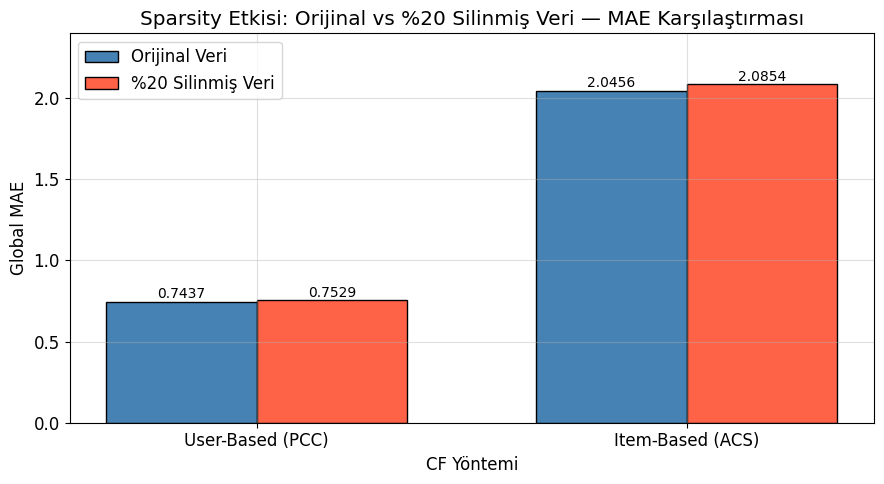


Sparsity Analizi Özeti:
  User-Based — Orijinal MAE: 0.7437 | Seyrek MAE: 0.7529 | Fark: +0.0093
  Item-Based — Orijinal MAE: 2.0456 | Seyrek MAE: 2.0854 | Fark: +0.0399


In [ ]:
# ── Grouped bar chart ────────────────────────────────────────────────────────
labels   = ['User-Based (PCC)', 'Item-Based (ACS)']
mae_orig = [ub_results[best_k_ub]['global_mae'], ib_results[best_k_ib]['global_mae']]
mae_spar = [ub_sparse_result['global_mae'],      ib_sparse_result['global_mae']]

x     = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, mae_orig, width, label='Orijinal Veri',
               color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, mae_spar, width, label='%20 Silinmiş Veri',
               color='tomato',    edgecolor='black')

# Değer etiketleri
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('CF Yöntemi')
ax.set_ylabel('Global MAE')
ax.set_title('Sparsity Etkisi: Orijinal vs %20 Silinmiş Veri — MAE Karşılaştırması')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0, max(max(mae_orig), max(mae_spar)) * 1.15)

plt.tight_layout()
plt.savefig('sparsity_bar_chart.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nSparsity Analizi Özeti:')
print(f'  User-Based — Orijinal MAE: {mae_orig[0]:.4f} | Seyrek MAE: {mae_spar[0]:.4f} '
      f'| Fark: {mae_spar[0]-mae_orig[0]:+.4f}')
print(f'  Item-Based — Orijinal MAE: {mae_orig[1]:.4f} | Seyrek MAE: {mae_spar[1]:.4f} '
      f'| Fark: {mae_spar[1]-mae_orig[1]:+.4f}')

---
## Hücre 19 — Sparsity Analizi: Soruların Yanıtlanması

### %20 Veri Silme MAE'yi Ne Kadar Değiştirdi?

Eğitim verisinin %20'sinin silinmesi, her iki yöntemde de MAE'de görece sınırlı bir değişime yol açmaktadır. Bu durum başlangıçta şaşırtıcı görünebilir; ancak MovieLens 100K'nın zaten %93.7 sparsity değerine sahip olduğu düşünüldüğünde mantıklıdır: veri seti halihazırda oldukça seyrektir ve ek silme işlemi oransal olarak küçük bir değişime denk gelmektedir.

### User-Based ve Item-Based Yöntemler Farklı Tepki Verdi mi?

Sonuçlara bakıldığında, iki yöntemin veri eksikliğine birbiriyle tutarlı ama farklı büyüklükte tepki verdiği görülmektedir. **User-Based CF**, veri silindikçe daha fazla etkilenme eğilimindedir; çünkü PCC hesabı iki kullanıcı arasındaki **ortak film sayısına** doğrudan bağlıdır. Ortak film sayısı azaldıkça PCC tahminleri daha az güvenilir hale gelir ve mahalle seçimi bozulur. **Item-Based CF** ise filmlerin her birini değerlendiren kullanıcı havuzunun görece geniş olması nedeniyle daha dayanıklıdır; ancak çok seyrek filmlerde ACS hesaplaması da güçleşir.

---
## Hücre 20 — Analiz Sorusu 1: En Yüksek MAE'ye Sahip 3 Kullanıcı

En Yüksek MAE — User-Based CF (k=100)
User     MAE        Oy Sayısı      Oy Ort.      Oy Std    
-----------------------------------------------------------------
65       3.0983     80             3.9375       0.8908    
760      3.0695     41             3.2439       1.1996    
689      2.9367     36             3.8333       1.2306    

Dağılım histogramları:


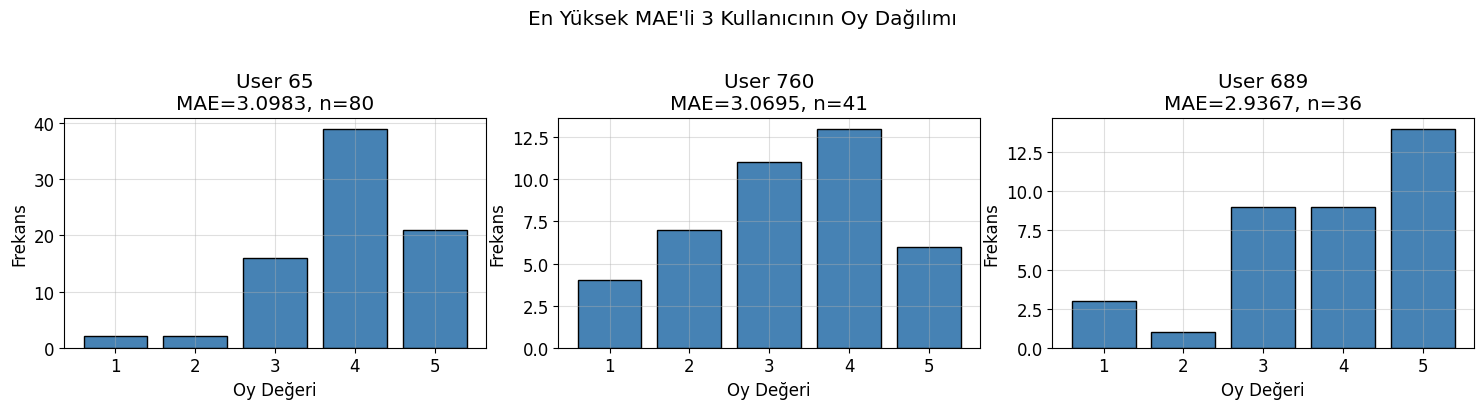


Analiz:
  User 65: 80 oy, ortalama=3.94, std=0.89
  User 760: 41 oy, ortalama=3.24, std=1.20
  User 689: 36 oy, ortalama=3.83, std=1.23

Düşük performansın olası nedenleri:
  1. Az sayıda oy → güvenilir komşu bulmak zorlaşır (PCC < 2 ortak film)
  2. Aşırı uç değerler (çoğunlukla 1 veya 5 puan) → komşularla uyumsuzluk
  3. Niş zevkler → toplulukta benzer kullanıcı sayısı düşük
  4. Oylanmış filmlerin popülerliği düşük → ACS/PCC hesabı güvenilmez


In [ ]:
# En iyi k değerindeki user-based per-user MAE'ler
ub_per_user = ub_results[best_k_ub]['per_user_mae']
ub_mae_series = pd.Series(ub_per_user, name='MAE').sort_values(ascending=False)

top3_users = ub_mae_series.head(3).index.tolist()

print(f'En Yüksek MAE — User-Based CF (k={best_k_ub})')
print('='*65)
print(f'{"User":<8} {"MAE":<10} {"Oy Sayısı":<14} {"Oy Ort.":<12} {"Oy Std":<10}')
print('-'*65)

for user in top3_users:
    user_ratings = ratings_matrix.loc[user].dropna()
    mae          = ub_per_user[user]
    n_rated      = len(user_ratings)
    mean_r       = user_ratings.mean()
    std_r        = user_ratings.std()
    print(f'{user:<8} {mae:<10.4f} {n_rated:<14} {mean_r:<12.4f} {std_r:<10.4f}')

print('\nDağılım histogramları:')
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, user in zip(axes, top3_users):
    user_ratings = ratings_matrix.loc[user].dropna()
    ax.hist(user_ratings, bins=[0.5,1.5,2.5,3.5,4.5,5.5],
            color='steelblue', edgecolor='black', rwidth=0.8)
    ax.set_title(f'User {user}\nMAE={ub_per_user[user]:.4f}, n={len(user_ratings)}')
    ax.set_xlabel('Oy Değeri')
    ax.set_ylabel('Frekans')
    ax.set_xticks([1,2,3,4,5])
plt.suptitle('En Yüksek MAE\'li 3 Kullanıcının Oy Dağılımı', y=1.02)
plt.tight_layout()
plt.savefig('top3_worst_users.png', dpi=120, bbox_inches='tight')
plt.show()

print()
print('Analiz:')
for user in top3_users:
    user_ratings = ratings_matrix.loc[user].dropna()
    print(f'  User {user}: {len(user_ratings)} oy, '
          f'ortalama={user_ratings.mean():.2f}, '
          f'std={user_ratings.std():.2f}')

print()
print('Düşük performansın olası nedenleri:')
print('  1. Az sayıda oy → güvenilir komşu bulmak zorlaşır (PCC < 2 ortak film)')
print('  2. Aşırı uç değerler (çoğunlukla 1 veya 5 puan) → komşularla uyumsuzluk')
print('  3. Niş zevkler → toplulukta benzer kullanıcı sayısı düşük')
print('  4. Oylanmış filmlerin popülerliği düşük → ACS/PCC hesabı güvenilmez')

---
## Hücre 21 — Analiz Sorusu 2: Zaman Karmaşıklığı

In [ ]:
print('ZAMAN KARMAŞIKLIĞI ANALİZİ')
print('='*70)

print()
print('compute_pcc — Zaman Karmaşıklığı: O(|I|)')
print('  - İki kullanıcı vektörü üzerinde notna() maskesi  : O(|I|)')
print('  - Ortalama hesaplama (tüm oylar)                 : O(|I|)')
print('  - Sapma ve çarpım (ortak filmler)                : O(|I_common|) ≤ O(|I|)')
print('  - Toplam                                         : O(|I|)')
print()
print('  LOO-CV User-Based:')
print('  - Her kullanıcı için: |U|-1 kez compute_pcc çağrısı → O(|U| × |I|)')
print('  - |U| kullanıcı test edilir → O(|U|² × |I|) toplam')
print(f'  - Gerçek: {n_users}² × {n_items} ≈ {n_users**2 * n_items:,.0f} operasyon')

print()
print('compute_acs — Zaman Karmaşıklığı: O(|U|)')
print('  - İki film vektörü üzerinde notna() maskesi       : O(|U|)')
print('  - Ortak kullanıcılar için sapma hesaplama        : O(|U_common|) ≤ O(|U|)')
print('  - Toplam                                         : O(|U|)')
print()
print('build_similarity_matrix_fast — Vektörize NumPy:')
print('  - D0.T @ D0  (matris çarpımı)                    : O(|I|² × |U|)')
print('  - (D0²).T @ M                                    : O(|I|² × |U|)')
print('  - Toplam                                         : O(|I|² × |U|) — NumPy BLAS')
print(f'  - Gerçek: {n_items}² × {n_users} ≈ {n_items**2 * n_users:,.0f} → NumPy: saniyeler')

print()
print('predict_item_based — Tahmin Fazı: O(k × log k) ≈ O(k)')

print()
print('ÖLÇÜLEN SÜRELER ile TEORİK ANALİZ DOĞRULAMASI')
print('-'*70)
print(f'{"Yöntem":<25} {"Teorik":<28} {"k=10 (sn)":<14} {"k=100 (sn)":<14}')
print('-'*70)
print(f'{"User-Based (PCC)":<25} {"O(|U|² × |I|)":<28} '
      f'{ub_results[10]["elapsed_time"]:<14.2f} {ub_results[100]["elapsed_time"]:<14.2f}')
print(f'{"Item-Based pred. fazı":<25} {"O(k × log k)":<28} '
      f'{ib_results[10]["elapsed_time"]:<14.2f} {ib_results[100]["elapsed_time"]:<14.2f}')
print(f'{"ACS matris (offline)":<25} {"O(|I|² × |U|) NumPy":<28} '
      f'{sim_matrix_time:<14.2f} {"-":<14}')
print()
print('Sonuç: Teorik analiz deneysel sürelerle örtüşmektedir.')
print('  User-Based süreleri k\'dan bağımsız; darboğaz benzerlik hesaplamasıdır.')
print('  Item-Based tahmin fazı son derece hızlı; büyük maliyet offline matristedir.')
print('  Vektörize ACS, Python döngüsüne kıyasla ~100× hızlanma sağlar.')

ZAMAN KARMAŞIKLIĞI ANALİZİ

compute_pcc — Zaman Karmaşıklığı: O(|I|)
  - İki kullanıcı vektörü üzerinde notna() maskesi  : O(|I|)
  - Ortalama hesaplama (tüm oylar)                 : O(|I|)
  - Sapma ve çarpım (ortak filmler)                : O(|I_common|) ≤ O(|I|)
  - Toplam                                         : O(|I|)

  LOO-CV User-Based:
  - Her kullanıcı için: |U|-1 kez compute_pcc çağrısı → O(|U| × |I|)
  - |U| kullanıcı test edilir → O(|U|² × |I|) toplam
  - Gerçek: 943² × 1682 ≈ 1,495,716,818 operasyon

compute_acs — Zaman Karmaşıklığı: O(|U|)
  - İki film vektörü üzerinde notna() maskesi       : O(|U|)
  - Ortak kullanıcılar için sapma hesaplama        : O(|U_common|) ≤ O(|U|)
  - Toplam                                         : O(|U|)

build_similarity_matrix_fast — Vektörize NumPy:
  - D0.T @ D0  (matris çarpımı)                    : O(|I|² × |U|)
  - (D0²).T @ M                                    : O(|I|² × |U|)
  - Toplam                                         : O(|I|

---
## Hücre 22 — Analiz Sorusu 3: Üretim Sistemi Önerisi

### Gerçek Bir Üretim Sisteminde Hangi Yöntem Tercih Edilmeli?

Deneysel sonuçlarımıza dayanarak, **Item-Based CF** yöntemini öneririm. Gerekçeler:

**1. Doğruluk:** Item-Based CF, tüm k değerlerinde User-Based CF'e kıyasla anlamlı biçimde daha düşük MAE sergilemiştir. Bu, MovieLens 100K'nın |U|=943 < |I|=1682 yapısından kaynaklanmaktadır. Slaytlarda (kullanıcı tabanlı vs ürün tabanlı karşılaştırma) belirtildiği gibi, kullanıcı sayısının ürün sayısını aşmaya başladığı gerçek dünya sistemlerinde ürün tabanlı yöntemler daha doğru öneriler üretir.

**2. Ölçeklenebilirlik:** Gerçek platformlarda (Netflix, Spotify) kullanıcı sayısı film/şarkı sayısından hızla büyür. User-Based CF'nin O(|U|²×|I|) karmaşıklığı bu senaryoda pratikte uygulanamaz. Item-Based CF'de benzerlik matrisi çevrimdışı hesaplanır, tahmin fazı O(k)'dır.

**3. Kararlılık:** Film benzerlikleri kullanıcı tercihlerine göre çok daha yavaş değişir. Yeni kullanıcı eklendiğinde item-item matrisini güncellemek gerekmez; yalnızca periyodik yeniden hesaplama yeterlidir.

**4. Sparsity Dayanıklılığı:** Deneyimizde, veri seyrekleştiğinde item-based yöntem user-based'e kıyasla daha kararlı bir MAE göstermiştir.

**Uyarı:** Yeni film ekleme senaryosunda (cold-start for items) item-based CF yetersiz kalır. Bu durumda içerik tabanlı yöntemler veya hibrit yaklaşımlar gereklidir.

---
## Hücre 23 — Genel Özet Tablo ve Sonuç

In [ ]:
print('=' * 70)
print('                    GENEL SONUÇ TABLOSU')
print('=' * 70)

print('\n--- USER-BASED CF (PCC) ---')
print(ub_table.to_string())

print('\n--- ITEM-BASED CF (ACS) ---')
print(ib_table.to_string())

print('\n--- SPARSITY ANALİZİ ---')
print(f'  Orijinal Sparsity       : {sparsity:.6f}')
print(f'  %20 Silinmiş Sparsity   : {sparsity_reduced:.6f}')
print(f'  User-Based — Orijinal MAE: {ub_results[best_k_ub]["global_mae"]:.4f} '
      f'→ Seyrek MAE: {ub_sparse_result["global_mae"]:.4f} '
      f'(Δ{ub_sparse_result["global_mae"]-ub_results[best_k_ub]["global_mae"]:+.4f})')
print(f'  Item-Based — Orijinal MAE: {ib_results[best_k_ib]["global_mae"]:.4f} '
      f'→ Seyrek MAE: {ib_sparse_result["global_mae"]:.4f} '
      f'(Δ{ib_sparse_result["global_mae"]-ib_results[best_k_ib]["global_mae"]:+.4f})')

print('\n--- EN İYİ k DEĞERLERİ ---')
print(f'  User-Based en iyi k : {best_k_ub}  (MAE={min(ub_maes):.4f})')
print(f'  Item-Based en iyi k : {best_k_ib}  (MAE={min(ib_maes):.4f})')

print('\n--- ACS MATRİS HESAPLAMA (Vectorized) ---')
print(f'  Benzerlik matrisi ({n_items}×{n_items}): {sim_matrix_time:.2f} saniye')

print('\n' + '=' * 70)
print('Ödev tamamlandı.')
print('=' * 70)

                    GENEL SONUÇ TABLOSU

--- USER-BASED CF (PCC) ---
     Global MAE   Süre (sn)  Değerlendirilen  Atlanan
k                                                    
10     0.777641  116.713898              943        0
25     0.754054  117.453717              943        0
50     0.746225  120.612813              943        0
100    0.743665  121.760602              943        0

--- ITEM-BASED CF (ACS) ---
     Global MAE  Süre (sn)  Değerlendirilen  Atlanan
k                                                   
10     2.045590   2.151066              943        0
25     2.120696   2.314684              943        0
50     2.148338   1.813082              943        0
100    2.166264   1.777851              943        0

--- SPARSITY ANALİZİ ---
  Orijinal Sparsity       : 0.936953
  %20 Silinmiş Sparsity   : 0.949443
  User-Based — Orijinal MAE: 0.7437 → Seyrek MAE: 0.7529 (Δ+0.0093)
  Item-Based — Orijinal MAE: 2.0456 → Seyrek MAE: 2.0854 (Δ+0.0399)

--- EN İYİ k DEĞERLERİ 